#OCR clean

In [ ]:

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q pymupdf pandas pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.1/329.1 kB 30.9 MB/s eta 0:00:00


#vocab

In [ ]:
import re
import json
import os
from pathlib import Path

CLEAN_TEXT_DIR = Path("/content/drive/MyDrive/medical_protocols/processed_data/cleaned_text")
dict_output_path = "/content/drive/MyDrive/medical_protocols/processed_data/abbreviation_dict.json"

def extract_abbreviations(text):
    abbrev_map = {}

    matches = re.findall(r'^([А-ЯA-Z]{2,10})\s+[–\-]\s+(.+)$', text, re.MULTILINE)

    for abbrev, full_form in matches:
        abbrev_map[abbrev.strip()] = full_form.strip()
    return abbrev_map

global_dict = {}

for filename in os.listdir(CLEAN_TEXT_DIR):
    if filename.endswith(".txt"):
        with open(CLEAN_TEXT_DIR / filename, 'r', encoding='utf-8') as f:
            content = f.read()
            file_abbrevs = extract_abbreviations(content)
            global_dict.update(file_abbrevs)

with open(dict_output_path, "w", encoding="utf-8") as f:
    json.dump(global_dict, f, ensure_ascii=False, indent=4)

print(f"Собрано уникальных сокращений: {len(global_dict)}")

✅ Собрано уникальных сокращений: 426


#new clean

In [ ]:
import os
from google.colab import files

pdf_filename = "/content/Медицинский_аборт.pdf"
output_dir = "/content/output"

!marker_single "{pdf_filename}" --output_dir "{output_dir}"

if os.path.exists(output_dir) and os.listdir(output_dir):
    print(f"\n--- УСПЕХ! ---")
    for root, dirs, files in os.walk(output_dir):
        for name in files:
            if name.endswith(".md"):
                print(f"Файл создан: {os.path.join(root, name)}")
else:
    print("\nОшибка: Файл не создан. Попробуем проверить доступные опции...")
    !marker_single --help

2026-01-30 10:26:58.883404: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 10:26:58.901123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769768818.923291    3895 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769768818.930003    3895 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769768818.946821    3895 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
import os
import glob
from google.colab import drive
from docling.document_converter import DocumentConverter
drive.mount('/content/drive')
input_folder = "/content/drive/MyDrive/medical_protocols"
output_folder = "/content/drive/MyDrive/medical_protocols/processed_markdowns"
os.makedirs(output_folder, exist_ok=True)
pdf_files = glob.glob(os.path.join(input_folder, "*.pdf"))
if not pdf_files:
    print(f"PDF '{input_folder}' не найдены.")
else:
    print(f"Найдено файлов {len(pdf_files)}")
    converter = DocumentConverter()
    for pdf_path in pdf_files:
        file_name = os.path.basename(pdf_path)
        md_name = file_name.replace(".pdf", ".md")
        output_path = os.path.join(output_folder, md_name)

        print(f"Docling: {file_name}...")

        try:
            result = converter.convert(pdf_path)
            markdown_output = result.document.export_to_markdown()

            with open(output_path, "w", encoding="utf-8") as f:
                f.write(markdown_output)
            print(f"Готово: {md_name}")
        except Exception as e:
            print(f"Ошибка в файле {file_name}: {e}")
    print(f"\n--- ПАКЕТНАЯ ОБРАБОТКА ЗАВЕРШЕНА ---")
    print(f"Все .md файлы сохранены в папке Colab: {output_folder}")



In [ ]:
import pandas as pd
import os

output_folder = "/content/drive/MyDrive/medical_protocols/processed_markdowns"
md_files = [f for f in os.listdir(output_folder) if f.endswith('.md')]

report = []
for md_file in md_files:
    file_path = os.path.join(output_folder, md_file)
    size = os.path.getsize(file_path)
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        tables_count = content.count('|---|') + content.count('| --- |')

    report.append({
        "Название протокола": md_file,
        "Размер (КБ)": round(size / 1024, 2),
        "Примерное кол-во таблиц": tables_count,
        "Статус": "✅ Готов к NER"
    })

df_report = pd.DataFrame(report)
display(df_report.sort_values(by="Примерное кол-во таблиц", ascending=False).head(10))

In [ ]:
import re
import os
from pathlib import Path

def smart_fix_tables(text):
    text = re.sub(r'(?:(?<=\s)|(?<=^))([а-яА-ЯёЁ]\s){2,}[а-яА-ЯёЁ](?=\s|$|[.,])',
                  lambda m: m.group(0).replace(" ", ""), text)


    text = re.sub(r'([а-яА-ЯёЁ]{4,})\s([а-яА-ЯёЁ]{1,2})\b', r'\1\2', text)

    text = text.replace("мм . рт . ст", "мм.рт.ст")
    text = text.replace("мкмоль / л", "мкмоль/л")

    text = re.sub(r'(\d)\s(?=\d)', r'\1', text)

    return text

CLEANED_DIR = Path("/content/drive/MyDrive/medical_protocols/processed_data/normalized_text")

for filename in os.listdir(CLEANED_DIR):
    if filename.endswith(".txt"):
        path = CLEANED_DIR / filename
        with open(path, 'r', encoding='utf-8') as f:
            content = f.read()

        fixed_content = smart_fix_tables(content)

        with open(path, 'w', encoding='utf-8') as f:
            f.write(fixed_content)

print("Таблицы во всех 84 файлах очищены от разрывов!")

In [ ]:
import re
import os
from pathlib import Path

def sanitize_medical_protocol(text):

    text = re.sub(r'\[[\d\s,\\\-]+\]', '', text)


    stop_phrases = [
        r'##\s*\d*\.?\s*Список\s*использованной\s*литературы',
        r'##\s*\d*\.?\s*Список\s*разработчиков',
        r'##\s*\d*\.?\s*ОРГАНИЗАЦИОННЫЕ\s*АСПЕКТЫ',
        r'##\s*\d*\.?\s*Список\s*рецензентов'
    ]

    for phrase in stop_phrases:
        parts = re.split(phrase, text, flags=re.IGNORECASE)
        if len(parts) > 1:
            text = parts[0] # Оставляем только то, что ДО этого заголовка

    text = re.sub(r'\n\s*\n+', '\n\n', text)

    return text.strip()

input_dir = Path("/content/drive/MyDrive/medical_protocols/processed_markdowns")
output_dir = Path("/content/drive/MyDrive/medical_protocols/gold_standard_md")
output_dir.mkdir(exist_ok=True)

for md_file in os.listdir(input_dir):
    if md_file.endswith(".md"):
        with open(input_dir / md_file, 'r', encoding='utf-8') as f:
            content = f.read()

        clean_content = sanitize_medical_protocol(content)

        with open(output_dir / md_file, 'w', encoding='utf-8') as f:
            f.write(clean_content)

print("✨ Все протоколы очищены от ссылок и организационного мусора!")

# new translate

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes sentencepiece tqdm

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import os
import re
import gc
import json
from pathlib import Path
from tqdm import tqdm

model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16, # bfloat16 идеально для A100
    device_map="auto"
)

INPUT_DIR = Path("/content/drive/MyDrive/medical_protocols/gold_standard_md")
OUTPUT_DIR = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def clean_medical_text(text):
    """Удаляет ссылки [1, 2, 3] и технические разделы в конце"""
    text = re.sub(r'\[[\d\s,\\\-]+\]', '', text)

    stop_phrases = [
        r'##\s*\d*\.?\s*Список\s*использованной\s*литературы',
        r'##\s*\d*\.?\s*Список\s*разработчиков',
        r'##\s*\d*\.?\s*ОРГАНИЗАЦИОННЫЕ\s*АСПЕКТЫ'
    ]
    for phrase in stop_phrases:
        parts = re.split(phrase, text, flags=re.IGNORECASE)
        if len(parts) > 1:
            text = parts[0]

    return text.strip()

def split_text_smartly(text, max_chars=2000):
    """Разбивает текст по заголовкам или абзацам для стабильности на A100"""
    sections = re.split(r'(?=##\s)', text)
    final_chunks = []

    for section in sections:
        if len(section) <= max_chars:
            final_chunks.append(section)
        else:
            paragraphs = section.split('\n\n')
            buffer = ""
            for para in paragraphs:
                if len(buffer) + len(para) < max_chars:
                    buffer += para + "\n\n"
                else:
                    if buffer: final_chunks.append(buffer.strip())
                    buffer = para + "\n\n"
            if buffer:
                final_chunks.append(buffer.strip())

    return [c for c in final_chunks if c.strip()]

def translate_and_extract(chunk, part_idx, total_parts):
    system_instruction = (
        "You are a professional medical translator. Translate the clinical protocol from Russian to English. "
        "STRICT RULES:\n"
        "1. WORD-FOR-WORD FIDELITY: Translate every sentence. Do not shorten, simplify, or summarize.\n"
        "2. NO SKIPPING: Translate all table contents and bullet points.\n"
        "3. DRUGS: Keep drug names as International Nonproprietary Names (INN). Do not translate them to brand names.\n"
        "4. SCALES: Do not translate SOFA, qSOFA, ICD-10 codes.\n"
        "5. OUTPUT: Provide the translation, then the header '---DRUGS---' with a comma-separated list of found drugs."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": f"Part {part_idx+1}/{total_parts}. Strictly translate:\n\n{chunk}"}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2500,
            do_sample=False,
            temperature=0.01,
            repetition_penalty=1.1
        )

    generated_ids = outputs[0][inputs.input_ids.shape[-1]:]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    if "---DRUGS---" in full_response:
        translation, drug_list = full_response.split("---DRUGS---")
        drugs = [d.strip() for d in drug_list.split(",") if d.strip()]
    else:
        translation = full_response
        drugs = []

    return translation.strip(), drugs

files = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith(".md")])

print(f"Найдено протоколов: {len(files)}")

for filename in tqdm(files, desc="Protocols Progress"):
    output_path = OUTPUT_DIR / f"en_{filename}"
    drug_json_path = OUTPUT_DIR / f"drugs_{filename.replace('.md', '.json')}"

    if output_path.exists() and drug_json_path.exists():
        continue

    with open(INPUT_DIR / filename, 'r', encoding='utf-8') as f:
        raw_content = f.read()

    content = clean_medical_text(raw_content)
    chunks = split_text_smartly(content, max_chars=2000)

    translated_parts = []
    all_drugs = set()

    print(f"\nФайл: {filename} | Разбивка: {len(chunks)} частей")

    success = True
    for i, chunk in enumerate(chunks):
        try:
            print(f"  Чанк {i+1}/{len(chunks)}...", end="")
            text_en, drugs = translate_and_extract(chunk, i, len(chunks))
            translated_parts.append(text_en)
            all_drugs.update(drugs)

            torch.cuda.empty_cache()
            gc.collect()
            print(" ОК")
        except Exception as e:
            print(f"\nОшибка в {filename} на части {i}: {e}")
            success = False
            break

    if success:
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write("\n\n".join(translated_parts))

        with open(drug_json_path, 'w', encoding='utf-8') as f:
            json.dump(list(all_drugs), f, ensure_ascii=False, indent=4)

        print(f"Успешно завершен: {output_path.name}")

print("\n ВСЕ ОБРАБОТАНЫ!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 51.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

 ОК
Успешно завершен: en_Хронические_воспалительные_болезни_матки_(хронический эндометрит).md

Файл: Эмболия_околоплодными_водами.md | Разбивка: 40 частей
  Чанк 1/40... ОК
  Чанк 2/40... ОК
  Чанк 3/40... ОК
  Чанк 4/40... ОК
  Чанк 5/40... ОК
  Чанк 6/40... ОК
  Чанк 7/40... ОК
  Чанк 8/40... ОК
  Чанк 9/40... ОК
  Чанк 10/40... ОК
  Чанк 11/40... ОК
  Чанк 12/40... ОК
  Чанк 13/40... ОК
  Чанк 14/40... ОК
  Чанк 15/40... ОК
  Чанк 16/40... ОК
  Чанк 17/40... ОК
  Чанк 18/40... ОК
  Чанк 19/40... ОК
  Чанк 20/40... ОК
  Чанк 21/40... ОК
  Чанк 22/40... ОК
  Чанк 23/40... ОК
  Чанк 24/40... ОК
  Чанк 25/40... ОК
  Чанк 26/40... ОК
  Чанк 27/40... ОК
  Чанк 28/40... ОК
  Чанк 29/40... ОК
  Чанк 30/40... ОК
  Чанк 31/40... ОК
  Чанк 32/40... ОК
  Чанк 33/40... ОК
  Чанк 34/40... ОК
  Чанк 35/40... ОК
  Чанк 36/40... ОК
  Чанк 37/40... ОК
  Чанк 38/40... ОК
  Чанк 39/40... ОК
  Чанк 40/40...

Protocols Progress:  99%|█████████▉| 83/84 [7:53:02<08:45, 525.85s/it]

 ОК
Успешно завершен: en_Эмболия_околоплодными_водами.md

Файл: Эрозия,_эктопия_и_эктропион_шейки_матки.md | Разбивка: 77 частей
  Чанк 1/77... ОК
  Чанк 2/77... ОК
  Чанк 3/77... ОК
  Чанк 4/77... ОК
  Чанк 5/77... ОК
  Чанк 6/77... ОК
  Чанк 7/77... ОК
  Чанк 8/77... ОК
  Чанк 9/77... ОК
  Чанк 10/77... ОК
  Чанк 11/77... ОК
  Чанк 12/77... ОК
  Чанк 13/77... ОК
  Чанк 14/77... ОК
  Чанк 15/77... ОК
  Чанк 16/77... ОК
  Чанк 17/77... ОК
  Чанк 18/77... ОК
  Чанк 19/77... ОК
  Чанк 20/77... ОК
  Чанк 21/77... ОК
  Чанк 22/77... ОК
  Чанк 23/77... ОК
  Чанк 24/77... ОК
  Чанк 25/77... ОК
  Чанк 26/77... ОК
  Чанк 27/77... ОК
  Чанк 28/77... ОК
  Чанк 29/77... ОК
  Чанк 30/77... ОК
  Чанк 31/77... ОК
  Чанк 32/77... ОК
  Чанк 33/77... ОК
  Чанк 34/77... ОК
  Чанк 35/77... ОК
  Чанк 36/77... ОК
  Чанк 37/77... ОК
  Чанк 38/77... ОК
  Чанк 39/77... ОК
  Чанк 40/77... ОК
  Чанк 41/77... ОК
  Чанк 42/77... ОК
  Чанк 43/77... ОК
  Чанк 44/77... ОК
  Чанк 45/77... ОК
  Чанк 46/77... ОК
  Чан

Protocols Progress: 100%|██████████| 84/84 [8:02:36<00:00, 344.72s/it]

 ОК
Успешно завершен: en_Эрозия,_эктопия_и_эктропион_шейки_матки.md

 ВСЕ ОБРАБОТАНЫ!


In [ ]:
!pip -q install -U "bitsandbytes>=0.46.1" "accelerate>=0.30.0"
!pip -q install -U "transformers>=4.41.0" "sentencepiece" "scikit-learn"

In [ ]:
# ============================================================
# FIND MISSING PROTOCOL(S) + TRANSLATE ONLY THE MISSING ONES
# (exact same translation style as before; no full rerun)
# ============================================================

import os, re, gc, json
from pathlib import Path
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


RU_DIR      = Path("/content/drive/MyDrive/medical_protocols/gold_standard_md")          # RU cleaned md
EN_FIXEDDIR = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")          # fixed EN
OUT_EN_DIR  = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama") # original EN outputs (where en_*.md and drugs_*.json live)

OUT_EN_DIR.mkdir(parents=True, exist_ok=True)

def ru_to_en_name(ru_filename: str) -> str:
    return f"en_{ru_filename}"

def clean_medical_text(text: str) -> str:
    text = re.sub(r"\[[\d\s,\-–]+\]", "", text)

    stop_phrases = [
        r"##\s*\d*\.?\s*Список\s*использованной\s*литературы",
        r"##\s*\d*\.?\s*Список\s*разработчиков",
        r"##\s*\d*\.?\s*ОРГАНИЗАЦИОННЫЕ\s*АСПЕКТЫ",
        r"##\s*\d*\.?\s*Список\s*рецензентов",
    ]
    for phrase in stop_phrases:
        parts = re.split(phrase, text, flags=re.IGNORECASE)
        if len(parts) > 1:
            text = parts[0]
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    return text.strip()

def split_text_smartly(text: str, max_chars: int = 2000):
    sections = re.split(r"(?=##\s)", text)
    chunks = []
    for section in sections:
        if len(section) <= max_chars:
            chunks.append(section)
        else:
            paragraphs = section.split("\n\n")
            buf = ""
            for para in paragraphs:
                para = para.strip()
                if not para:
                    continue
                if len(buf) + len(para) + 2 <= max_chars:
                    buf += para + "\n\n"
                else:
                    if buf.strip():
                        chunks.append(buf.strip())
                    buf = para + "\n\n"
            if buf.strip():
                chunks.append(buf.strip())
    return [c for c in chunks if c.strip()]

def translate_and_extract(chunk: str, part_idx: int, total_parts: int, tokenizer, model):
    system_instruction = (
        "You are a professional medical translator. Translate the clinical protocol from Russian to English. "
        "STRICT RULES:\n"
        "1. WORD-FOR-WORD FIDELITY: Translate every sentence. Do not shorten, simplify, or summarize.\n"
        "2. NO SKIPPING: Translate all table contents and bullet points.\n"
        "3. DRUGS: Keep drug names as International Nonproprietary Names (INN). Do not translate them to brand names.\n"
        "4. SCALES: Do not translate SOFA, qSOFA, ICD-10 codes.\n"
        "5. OUTPUT: Provide the translation, then the header '---DRUGS---' with a comma-separated list of found drugs."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": f"Part {part_idx+1}/{total_parts}. Strictly translate:\n\n{chunk}"}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    device = model.device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2500,
            do_sample=False,
            temperature=0.01,
            repetition_penalty=1.1,
        )

    generated_ids = outputs[0][inputs.input_ids.shape[-1]:]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    if "---DRUGS---" in full_response:
        translation, drug_list = full_response.split("---DRUGS---", 1)
        drugs = [d.strip() for d in drug_list.split(",") if d.strip()]
    else:
        translation = full_response
        drugs = []

    return translation.strip(), drugs

ru_files = sorted([p.name for p in RU_DIR.glob("*.md")])
en_fixed_files = set([p.name for p in EN_FIXEDDIR.glob("en_*.md")])

expected_en = [ru_to_en_name(f) for f in ru_files]
missing = sorted([f for f in expected_en if f not in en_fixed_files])

print(f"RU protocols: {len(ru_files)}")
print(f"EN fixed:     {len(en_fixed_files)}")
print(f"Missing:      {len(missing)}")

if missing:
    print("\nMissing EN files:")
    for m in missing:
        print(" -", m)
else:
    print("\n✅ No missing EN files detected against RU_DIR.")

if missing:
    model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )

    for en_name in missing:
        ru_name = en_name.replace("en_", "", 1)
        ru_path = RU_DIR / ru_name

        if not ru_path.exists():
            print(f"⚠️ RU file not found for {en_name}: {ru_path}")
            continue

        out_en_path = OUT_EN_DIR / en_name
        out_drugs_path = OUT_EN_DIR / f"drugs_{ru_name.replace('.md', '.json')}"

        print(f"\nTranslating missing: {ru_name}")

        raw_ru = ru_path.read_text(encoding="utf-8", errors="ignore")
        content = clean_medical_text(raw_ru)
        chunks = split_text_smartly(content, max_chars=2000)

        translated_parts = []
        all_drugs = set()

        ok = True
        for i, chunk in enumerate(chunks):
            try:
                text_en, drugs = translate_and_extract(chunk, i, len(chunks), tokenizer, model)
                translated_parts.append(text_en)
                all_drugs.update(drugs)

                torch.cuda.empty_cache()
                gc.collect()
            except Exception as e:
                print(f"Error on {ru_name} chunk {i+1}/{len(chunks)}: {e}")
                ok = False
                break

        if ok:
            out_en_path.write_text("\n\n".join(translated_parts), encoding="utf-8")
            with open(out_drugs_path, "w", encoding="utf-8") as f:
                json.dump(sorted(all_drugs), f, ensure_ascii=False, indent=2)

            print(f"Saved: {out_en_path.name}")
        else:
            print(f"Skipped saving incomplete translation for: {ru_name}")

    print("\n➡️ After translating missing, re-run your postprocess fixer to copy it into en_aux_v1_fixed.")


RU protocols: 84
EN fixed:     83
Missing:      1

Missing EN files:
 - en_Доброкачественные_новообразования_молочной_железы.md


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


Translating missing: Доброкачественные_новообразования_молочной_железы.md


KeyboardInterrupt: 

#prep after translation

In [ ]:
# ============================================================
# POST-TRANSLATION PIPELINE (NO RE-TRANSLATION)
# Paste this AFTER your translation step.
#
# It will:
# 1) Fix EN files structure (move drug list to bottom, unify ---DRUGS--- block)
# 2) Apply minimal safe cleanup (whitespace only)
# 3) Run a quality gate (OK/WARN/FAIL) and save a report
# 4) Create a clean folder en_aux_v1_fixed/ for downstream NER/embeddings
# 5) (Optional) Add a META block to each file for versioning
# ============================================================

import re
import json
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, List

EN_INPUT_DIR = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama")
EN_FIXED_DIR = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
REPORT_PATH  = EN_FIXED_DIR / "_postprocess_report.json"

EN_FIXED_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------
# QUALITY / HEURISTICS
# ------------------------
DRUG_MARKER = "---DRUGS---"

# If body shorter than this, likely broken translation (e.g., drug list only)
MIN_BODY_CHARS = 2500

# If less than this headers count, we keep but mark WARN (some docs don't have markdown headers)
MIN_HEADERS_FOR_OK = 1

# Detect "drug list at top" if first line contains many commas and is mostly latin tokens
TOP_DRUGS_COMMAS = 10
MAX_TOP_LINE_LEN = 2000

ADD_META_BLOCK = True
META_BLOCK = (
    "\n\n---META---\n"
    "source_lang: ru\n"
    "translation_model: unsloth/llama-3-8b-Instruct-bnb-4bit\n"
    "corpus_version: en_aux_v1_fixed\n"
)

# ------------------------
# DATA STRUCTURES
# ------------------------
@dataclass
class FileReport:
    file: str
    status: str  # OK / WARN / FAIL
    reason: str
    body_chars: int
    header_count: int
    has_drugs_block: bool
    moved_top_drugs_to_bottom: bool
    repaired_whitespace: bool



def _count_headers(md: str) -> int:
    return len(re.findall(r"^##\s+", md, flags=re.M))


def _looks_like_drug_list_line(line: str) -> bool:
    line = line.strip()
    if not line or len(line) > MAX_TOP_LINE_LEN:
        return False
    if line.count(",") < TOP_DRUGS_COMMAS:
        return False
    return bool(re.fullmatch(r"[A-Za-z0-9\-\s,]+", line))


def _normalize_whitespace(text: str) -> Tuple[str, bool]:
    before = text
    text = re.sub(r"\n[ \t]*\n{2,}", "\n\n", text)
    text = re.sub(r"[ \t]+\n", "\n", text)
    text = text.strip()
    return text, (text != before.strip())


def _remove_duplicate_meta(md: str) -> str:
    parts = md.split("\n---META---")
    if len(parts) <= 1:
        return md
    return parts[0].strip()


def normalize_en_translation(md_text: str) -> Tuple[Optional[str], FileReport]:
    raw = md_text.strip()
    header_count = _count_headers(raw)

    moved_top_drugs = False
    repaired_ws = False

    drugs_block = ""
    body = raw

    if DRUG_MARKER in raw:
        body_part, drugs_part = raw.split(DRUG_MARKER, 1)
        body = body_part.strip()
        drugs_block = (DRUG_MARKER + "\n" + drugs_part.strip()).strip()

    lines = body.splitlines()
    if lines:
        first = lines[0].strip()
        if _looks_like_drug_list_line(first):
            moved_top_drugs = True
            if not drugs_block:
                drugs_block = (DRUG_MARKER + "\n" + first).strip()
            body = "\n".join(lines[1:]).strip()

    body, body_ws_changed = _normalize_whitespace(body)
    if drugs_block:
        drugs_block, drugs_ws_changed = _normalize_whitespace(drugs_block)
    else:
        drugs_ws_changed = False
    repaired_ws = body_ws_changed or drugs_ws_changed

    fixed = body
    if drugs_block:
        fixed = fixed + "\n\n" + drugs_block + "\n"

    body_chars = len(body)
    if body_chars < MIN_BODY_CHARS:
        status = "FAIL"
        reason = "Body too short; translation may be missing (possible drug-only output)."
    elif header_count < MIN_HEADERS_FOR_OK:
        status = "WARN"
        reason = "Low/no section headers detected; document may be OK but structure is weak."
    else:
        status = "OK"
        reason = "Normalized successfully."

    report = FileReport(
        file="",
        status=status,
        reason=reason,
        body_chars=body_chars,
        header_count=header_count,
        has_drugs_block=bool(drugs_block),
        moved_top_drugs_to_bottom=moved_top_drugs,
        repaired_whitespace=repaired_ws,
    )

    if status == "FAIL":
        return None, report
    return fixed, report


def process_existing_translations(
    en_input_dir: Path,
    en_fixed_dir: Path,
    add_meta_block: bool = True
) -> List[FileReport]:

    en_files = sorted([p for p in en_input_dir.glob("en_*.md") if p.is_file()])
    print(f"📄 Found EN translations: {len(en_files)}")

    reports: List[FileReport] = []

    for p in en_files:
        raw = p.read_text(encoding="utf-8", errors="ignore")
        fixed, rep = normalize_en_translation(raw)
        rep.file = p.name

        if fixed is not None:
            if add_meta_block:
                fixed_no_meta = _remove_duplicate_meta(fixed)
                fixed = fixed_no_meta + META_BLOCK

            (en_fixed_dir / p.name).write_text(fixed, encoding="utf-8")

        reports.append(rep)

    with open(REPORT_PATH, "w", encoding="utf-8") as f:
        json.dump([asdict(r) for r in reports], f, ensure_ascii=False, indent=2)

    ok = sum(r.status == "OK" for r in reports)
    warn = sum(r.status == "WARN" for r in reports)
    fail = sum(r.status == "FAIL" for r in reports)

    print(f"OK: {ok} | WARN: {warn} | FAIL: {fail}")
    print(f"Report saved: {REPORT_PATH}")
    print(f"Fixed EN saved in: {en_fixed_dir}")

    if fail > 0:
        print("\nFAIL files (excluded from fixed corpus):")
        for r in [x for x in reports if x.status == "FAIL"][:20]:
            print(f" - {r.file}: {r.reason} (body_chars={r.body_chars}, headers={r.header_count})")

    if warn > 0:
        print("\nWARN files (kept, but structure weak):")
        for r in [x for x in reports if x.status == "WARN"][:20]:
            print(f" - {r.file}: {r.reason} (body_chars={r.body_chars}, headers={r.header_count})")

    return reports



reports = process_existing_translations(
    en_input_dir=EN_INPUT_DIR,
    en_fixed_dir=EN_FIXED_DIR,
    add_meta_block=ADD_META_BLOCK
)

ready_files = [r.file for r in reports if r.status in ("OK", "WARN")]

with open(EN_FIXED_DIR / "_ner_ready_files.json", "w", encoding="utf-8") as f:
    json.dump(ready_files, f, ensure_ascii=False, indent=2)

print(f"\nNER-ready files list saved to: {EN_FIXED_DIR / '_ner_ready_files.json'}")
print("Next step: run NER on EN_FIXED_DIR only (use the ready_files list).")


📄 Found EN translations: 84
✅ OK: 84 | ⚠️ WARN: 0 | ❌ FAIL: 0
🧾 Report saved: /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed/_postprocess_report.json
📁 Fixed EN saved in: /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed

✅ NER-ready files list saved to: /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed/_ner_ready_files.json
➡️ Next step: run NER on EN_FIXED_DIR only (use the ready_files list).


In [ ]:
# RUN THIS BEFORE NER
import json
from pathlib import Path

EN_FIXED_DIR = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
REPORT_PATH = EN_FIXED_DIR / "_postprocess_report.json"

reports = process_existing_translations(
    en_input_dir=Path("/content/drive/MyDrive/medical_protocols/translated_english_llama"),
    en_fixed_dir=EN_FIXED_DIR
)

fail = [r for r in reports if r.status == "FAIL"]
warn = [r for r in reports if r.status == "WARN"]

print("FAIL:", len(fail))
for r in fail[:20]:
    print("-", r.file, "|", r.reason)

print("\nWARN:", len(warn))
for r in warn[:20]:
    print("-", r.file, "|", r.reason)

print("\nIf FAIL>0: do NOT include them in NER for now.")


📄 Found EN translations: 84
✅ OK: 84 | ⚠️ WARN: 0 | ❌ FAIL: 0
🧾 Report saved: /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed/_postprocess_report.json
📁 Fixed EN saved in: /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed
FAIL: 0

WARN: 0

✅ If FAIL>0: do NOT include them in NER for now.


In [ ]:
# ============================================================
# EN NER PIPELINE (BioBERT) on en_aux_v1_fixed
# - paragraph-based chunking (safer than raw char slicing)
# - correct global offsets (start/end aligned to full document)
# - resume: skips files if output exists
# - saves per-protocol JSON
# ============================================================

!pip -q install -U transformers accelerate torch sentencepiece tqdm

import os
import re
import json
from pathlib import Path
from tqdm import tqdm
from transformers import pipeline

EN_FIXED_DIR = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
NER_OUT_DIR  = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
NER_OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# NER MODEL
# -------------------------
# d4data/biomedical-ner-all is a strong all-round biomedical NER model
ner = pipeline(
    "ner",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple",
    device=0  # A100
)

# -------------------------
# CHUNKING (paragraph-based) + OFFSETS
# -------------------------
def chunk_by_paragraphs(text: str, max_chars: int = 1400):
    """
    Returns list of (chunk_start, chunk_text) where chunk_start is the
    position in the original full text (global offset).
    """
    paras = [p for p in text.split("\n\n") if p.strip()]
    chunks = []

    cursor = 0
    buf = ""
    buf_start = 0

    for p in paras:
        p_block = p.strip() + "\n\n"

        if not buf:
            buf_start = cursor

        if len(buf) + len(p_block) <= max_chars:
            buf += p_block
        else:
            if buf.strip():
                chunks.append((buf_start, buf.strip()))
            buf = p_block
            buf_start = cursor

        cursor += len(p_block)

    if buf.strip():
        chunks.append((buf_start, buf.strip()))

    return chunks

def run_ner_with_offsets(full_text: str, max_chars: int = 1400):
    chunks = chunk_by_paragraphs(full_text, max_chars=max_chars)
    entities = []

    for chunk_start, chunk in chunks:
        results = ner(chunk)
        for ent in results:
            entities.append({
                "entity_group": ent["entity_group"],
                "score": float(ent["score"]),
                "word": ent["word"],
                "start": int(ent["start"]) + int(chunk_start),
                "end": int(ent["end"]) + int(chunk_start),
            })
    return entities

en_files = sorted([p for p in EN_FIXED_DIR.glob("en_*.md") if p.is_file()])
print("EN files:", len(en_files))

for p in tqdm(en_files, desc="BioBERT NER"):
    out_path = NER_OUT_DIR / (p.stem.replace("en_", "ner_") + ".json")
    if out_path.exists():
        continue

    text = p.read_text(encoding="utf-8", errors="ignore")
    ents = run_ner_with_offsets(text, max_chars=1400)

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(
            {"file": p.name, "entities": ents},
            f,
            ensure_ascii=False,
            indent=2
        )

print("\nNER done. Results in:", NER_OUT_DIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

EN files: 84


BioBERT NER: 100%|██████████| 84/84 [01:06<00:00,  1.27it/s]


✅ NER done. Results in: /content/drive/MyDrive/medical_protocols/ner/en_biobert_v1


In [ ]:
import json
import re
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

NER_DIR = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
OUT_DIR = NER_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCORE_THRESH = 0.70

def norm_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s\-]", "", s)
    return s

files = sorted([p for p in NER_DIR.glob("ner_*.json") if p.is_file()])
print("NER json files:", len(files))

total_entities = 0
total_entities_hi = 0

per_file_counts = []
type_counter = Counter()
type_counter_hi = Counter()
mention_counter = Counter()
mention_counter_hi = Counter()

for p in files:
    data = json.loads(p.read_text(encoding="utf-8"))
    ents = data.get("entities", [])
    n_all = len(ents)
    n_hi = sum(1 for e in ents if float(e.get("score", 0)) >= SCORE_THRESH)

    total_entities += n_all
    total_entities_hi += n_hi

    per_file_counts.append({
        "file": data.get("file", p.name),
        "entities_all": n_all,
        "entities_hi": n_hi
    })

    for e in ents:
        g = e.get("entity_group", "UNK")
        w = norm_text(e.get("word", ""))
        sc = float(e.get("score", 0))

        if w:
            type_counter[g] += 1
            mention_counter[w] += 1

            if sc >= SCORE_THRESH:
                type_counter_hi[g] += 1
                mention_counter_hi[w] += 1

df = pd.DataFrame(per_file_counts)
df.to_csv(OUT_DIR / "ner_summary.csv", index=False)

summary = {
    "protocols": len(files),
    "score_threshold": SCORE_THRESH,
    "total_entities_all": total_entities,
    "total_entities_high_conf": total_entities_hi,
    "avg_entities_per_protocol_all": total_entities / max(1, len(files)),
    "avg_entities_per_protocol_high_conf": total_entities_hi / max(1, len(files)),
    "entity_types_all_top20": type_counter.most_common(20),
    "entity_types_high_conf_top20": type_counter_hi.most_common(20),
    "mentions_all_top20": mention_counter.most_common(20),
    "mentions_high_conf_top20": mention_counter_hi.most_common(20),
}

with open(OUT_DIR / "ner_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\n--- NER SUMMARY ---")
print("Protocols:", summary["protocols"])
print("Total entities (all):", summary["total_entities_all"])
print("Total entities (hi):", summary["total_entities_high_conf"])
print("Avg per protocol (all):", round(summary["avg_entities_per_protocol_all"], 2))
print("Avg per protocol (hi):", round(summary["avg_entities_per_protocol_high_conf"], 2))

print("\nTop entity types (hi-confidence):")
for t, c in summary["entity_types_high_conf_top20"]:
    print(f" - {t}: {c}")

print("\nTop mentions (hi-confidence):")
for m, c in summary["mentions_high_conf_top20"]:
    print(f" - {m}: {c}")

print("\nSaved:", OUT_DIR / "ner_summary.json")
print("Saved:", OUT_DIR / "ner_summary.csv")


NER json files: 84

--- NER SUMMARY ---
Protocols: 84
Total entities (all): 105082
Total entities (hi): 84237
Avg per protocol (all): 1250.98
Avg per protocol (hi): 1002.82

Top entity types (hi-confidence):
 - Diagnostic_procedure: 14517
 - Medication: 12131
 - Sign_symptom: 10820
 - Detailed_description: 7617
 - Biological_structure: 7471
 - Lab_value: 6452
 - Disease_disorder: 6236
 - Therapeutic_procedure: 5891
 - Dosage: 2521
 - Coreference: 1179
 - Severity: 1019
 - Subject: 1017
 - Administration: 991
 - Duration: 824
 - Clinical_event: 661
 - History: 534
 - Date: 523
 - Sex: 390
 - Nonbiological_location: 342
 - Frequency: 298

Top mentions (hi-confidence):
 - none: 537
 - tumor: 489
 - severe: 462
 - h: 382
 - pain: 353
 - intra: 346
 - ultrasound: 334
 - ce: 328
 - va: 319
 - bleeding: 315
 - ut: 313
 - women: 259
 - anti: 259
 - fe: 258
 - am: 250
 - oral: 250
 - ct: 250
 - normal: 246
 - kidney: 243
 - ur: 227

✅ Saved: /content/drive/MyDrive/medical_protocols/ner/en_biobe

In [ ]:
import json, re
from pathlib import Path
import pandas as pd

EN_DIR  = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
NER_DIR = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")

TARGETS = {"am", "ur", "h", "ce", "va"}
SCORE_MIN = 0.70
CONTEXT = 120

def norm(w: str) -> str:
    w = w.lower().strip()
    w = re.sub(r"\s+", " ", w)
    w = re.sub(r"[^\w\-]", "", w)
    return w

rows = []
ner_files = sorted(NER_DIR.glob("ner_*.json"))
print("NER files:", len(ner_files))

for nf in ner_files:
    data = json.loads(nf.read_text(encoding="utf-8"))
    en_name = data.get("file", "")
    if not en_name:
        # ner_XXX.json -> en_XXX.md
        stem = nf.stem.replace("ner_", "")
        en_name = f"en_{stem}.md"

    en_path = EN_DIR / en_name
    if not en_path.exists():
        continue

    text = en_path.read_text(encoding="utf-8", errors="ignore")
    ents = data.get("entities", [])

    for e in ents:
        w = norm(e.get("word", ""))
        sc = float(e.get("score", 0))
        if sc < SCORE_MIN:
            continue
        if w in TARGETS:
            s = int(e.get("start", 0))
            t = int(e.get("end", 0))

            left = max(0, s - CONTEXT)
            right = min(len(text), t + CONTEXT)
            snippet = text[left:right].replace("\n", " ")

            rows.append({
                "file": en_name,
                "entity_group": e.get("entity_group", ""),
                "score": sc,
                "word": e.get("word", ""),
                "word_norm": w,
                "start": s,
                "end": t,
                "context": snippet
            })

df = pd.DataFrame(rows).sort_values(["word_norm","score"], ascending=[True, False])
print("Matches found:", len(df))

display(df.head(30))

out_csv = NER_DIR / "abbr_noise_examples_en.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


NER files: 85
Matches found: 1506


,file,entity_group,score,word,word_norm,start,end,context
1230,en_Программа_донорства_ооцитов_спермы_эмбрионо...,Diagnostic_procedure,0.999948,am,am,5704,5706,----------------------------------------------...
1429,en_Хориоамнионит.md,Biological_structure,0.999944,am,am,388,390,"turient women, postpartum women. | ICD-10 | I..."
811,en_Маловодие_и_многоводие.md,Biological_structure,0.999917,am,am,24789,24791,ation with genetics to resolve the issue of in...
804,en_Маловодие_и_многоводие.md,Biological_structure,0.999911,am,am,10955,10957,- this may be the cause of incorrect fetal po...
1208,en_Преждевременный_разрыв_плодных_оболочек_До...,Diagnostic_procedure,0.999905,am,am,22123,22125,The duration of expectant management depends...
997,en_Оценка_функционального_состояния_плода.md,Diagnostic_procedure,0.999898,am,am,22476,22478,one episode of transition from flexed position...
176,en_Воспалительные_заболевания_промежности_вуль...,Medication,0.999892,am,am,1560,1562,age 1: Initial treatment with [medication name...
266,en_Выпадение_женских_половых_органов.md,Medication,0.999884,am,am,1938,1940,tment plan. * The patient should be advised to...
132,en_Ведение_беременных_с_митральным_стенозом.md,Medication,0.999884,am,am,55677,55679,should be carried out in accordance with the f...
187,en_Воспалительные_заболевания_промежности_вуль...,Medication,0.999882,am,am,17461,17463,se): List of main medications: Broad-spectru...


Saved: /content/drive/MyDrive/medical_protocols/ner/en_biobert_v1/abbr_noise_examples_en.csv


In [ ]:
# ============================================================
# FILTERED TOP MENTIONS FOR ANALYSIS / THESIS
# - keeps only clinically meaningful entity types
# - removes tokenization artifacts (am, ur, ce, etc.)
# - removes status words (none, normal)
# - DOES NOT modify raw NER data
# ============================================================

import json
import re
from pathlib import Path
from collections import Counter
import pandas as pd

NER_DIR = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
OUT_DIR = NER_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)


SCORE_THRESHOLD = 0.70

ALLOWED_TYPES = {
    "Medication",
    "Disease_disorder",
    "Diagnostic_procedure",
    "Therapeutic_procedure",
}

STATUS_WORDS = {
    "none", "normal", "unknown", "unspecified"
}

BAD_FRAGMENTS = {
    "anti", "intra", "pre", "post", "non"
}

# -------------------------
# NORMALIZATION
# -------------------------
def normalize_word(word: str) -> str:
    """
    Normalize surface form for frequency analysis.
    """
    w = word.lower().strip()
    w = re.sub(r"\s+", " ", w)
    w = re.sub(r"[^\w\s\-]", "", w)
    return w

# -------------------------
# CORE FILTER (FINAL, VALIDATED)
# -------------------------
def keep_for_analysis(word: str, entity_type: str) -> bool:
    w = normalize_word(word)

    # 1) keep only clinically relevant entity types
    if entity_type not in ALLOWED_TYPES:
        return False

    # 2) remove non-informative status tokens
    if w in STATUS_WORDS:
        return False

    # 3) remove short tokenization artifacts (am, ur, ce, h, etc.)
    if len(w) < 3:
        return False

    # 4) remove common subword fragments
    if w in BAD_FRAGMENTS:
        return False

    return True


mention_counter = Counter()
mention_counter_by_type = Counter()

files = sorted(NER_DIR.glob("ner_*.json"))
print("NER files:", len(files))

for p in files:
    data = json.loads(p.read_text(encoding="utf-8"))
    entities = data.get("entities", [])

    for e in entities:
        score = float(e.get("score", 0))
        if score < SCORE_THRESHOLD:
            continue

        word = e.get("word", "")
        etype = e.get("entity_group", "")

        if keep_for_analysis(word, etype):
            w_norm = normalize_word(word)
            mention_counter[w_norm] += 1
            mention_counter_by_type[(etype, w_norm)] += 1


top_mentions = mention_counter.most_common(30)

df_top = pd.DataFrame(
    top_mentions,
    columns=["mention", "count"]
)

df_top.to_csv(OUT_DIR / "top_mentions_filtered.csv", index=False)

with open(OUT_DIR / "top_mentions_filtered.json", "w", encoding="utf-8") as f:
    json.dump(top_mentions, f, ensure_ascii=False, indent=2)

print("\n--- TOP FILTERED MENTIONS ---")
for m, c in top_mentions[:20]:
    print(f"{m}: {c}")

print("\n✅ Saved:")
print(" - top_mentions_filtered.csv")
print(" - top_mentions_filtered.json")


NER files: 85

--- TOP FILTERED MENTIONS ---
ultrasound: 334
examination: 210
medications: 179
pro: 176
blood pressure: 149
cesarean section: 145
infection: 124
medication: 112
yst: 107
laboratory tests: 107
ctomy: 106
treatment: 99
insulin: 98
surgical intervention: 98
est: 97
drugs: 96
iron: 92
antibiotics: 91
lev: 87
blood: 86

✅ Saved:
 - top_mentions_filtered.csv
 - top_mentions_filtered.json


In [ ]:
from pathlib import Path
import json

NER_DIR = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
EN_DIR  = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")

ner_files = sorted([p for p in NER_DIR.glob("ner_*.json") if p.is_file()])
en_files  = sorted([p.name for p in EN_DIR.glob("en_*.md") if p.is_file()])

print("NER json:", len(ner_files))
print("EN md:   ", len(en_files))

ner_sources = []
for p in ner_files:
    data = json.loads(p.read_text(encoding="utf-8"))
    src = data.get("file", None)
    ner_sources.append((p.name, src))

bad = [(ner, src) for ner, src in ner_sources if (src is None or src not in set(en_files))]
print("\nNER files with missing/unknown source EN:")
for x in bad:
    print(" -", x)

ner_src_set = set([src for _, src in ner_sources if src])
missing_ner_for_en = sorted([f for f in en_files if f not in ner_src_set])

print("\nEN files without corresponding NER json:", len(missing_ner_for_en))
for f in missing_ner_for_en[:20]:
    print(" -", f)


NER json: 85
EN md:    84

NER files with missing/unknown source EN:
 - ('ner_summary.json', None)

EN files without corresponding NER json: 0


In [ ]:
BAD_FRAGMENTS = {
    "anti", "intra", "pre", "post", "non",
    "pro", "est", "lev", "yst", "ctomy"
}

def keep_for_analysis(word: str, entity_type: str) -> bool:
    w = normalize_word(word)

    if entity_type not in ALLOWED_TYPES:
        return False

    if w in STATUS_WORDS:
        return False

    if len(w) < 3:
        return False

    if w in BAD_FRAGMENTS:
        return False


    if w in {"ectomy", "ctomy"}:
        return False

    return True


In [ ]:
valid_en = set([p.name for p in EN_DIR.glob("en_*.md")])

files = []
for p in sorted(NER_DIR.glob("ner_*.json")):
    d = json.loads(p.read_text(encoding="utf-8"))
    if d.get("file") in valid_en:
        files.append(p)

print("Using valid NER files:", len(files))


Using valid NER files: 84


In [ ]:
import json
import re
from pathlib import Path
from collections import Counter
import pandas as pd

NER_DIR = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
EN_DIR  = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")


SCORE_THRESHOLD = 0.70

ALLOWED_TYPES = {
    "Medication",
    "Disease_disorder",
    "Diagnostic_procedure",
    "Therapeutic_procedure",
}

STATUS_WORDS = {"none", "normal", "unknown", "unspecified"}

BAD_FRAGMENTS = {
    "anti", "intra", "pre", "post", "non",
    "pro", "yst", "ctomy", "est", "lev",
    "prop", "hem"   # финальные хвосты
}
def normalize_word(word: str) -> str:
    w = word.lower().strip()
    w = re.sub(r"\s+", " ", w)
    w = re.sub(r"[^\w\s\-]", "", w)
    return w

def keep_for_analysis(word: str, entity_type: str) -> bool:
    w = normalize_word(word)

    if entity_type not in ALLOWED_TYPES:
        return False

    if w in STATUS_WORDS:
        return False

    # short artifacts (am/ur/ce/h etc.)
    if len(w) < 3:
        return False

    # fragments/tails
    if w in BAD_FRAGMENTS:
        return False

    return True

# -------------------------
# COLLECT ONLY REAL NER FILES
# -------------------------
valid_en = set([p.name for p in EN_DIR.glob("en_*.md") if p.is_file()])

ner_files = []
for p in sorted(NER_DIR.glob("ner_*.json")):
    data = json.loads(p.read_text(encoding="utf-8"))
    if data.get("file") in valid_en:
        ner_files.append(p)

print("Using NER files:", len(ner_files))  # should be 84

# -------------------------
# RECOMPUTE FILTERED TOP MENTIONS
# -------------------------
mention_counter = Counter()

for p in ner_files:
    data = json.loads(p.read_text(encoding="utf-8"))
    entities = data.get("entities", [])

    for e in entities:
        sc = float(e.get("score", 0))
        if sc < SCORE_THRESHOLD:
            continue
        word = e.get("word", "")
        etype = e.get("entity_group", "")
        if keep_for_analysis(word, etype):
            mention_counter[normalize_word(word)] += 1

top_mentions = mention_counter.most_common(30)

print("\n--- TOP FILTERED MENTIONS (v2) ---")
for m, c in top_mentions[:20]:
    print(f"{m}: {c}")

# save
df_top = pd.DataFrame(top_mentions, columns=["mention", "count"])
df_top.to_csv(NER_DIR / "top_mentions_filtered_v2.csv", index=False)
with open(NER_DIR / "top_mentions_filtered_v2.json", "w", encoding="utf-8") as f:
    json.dump(top_mentions, f, ensure_ascii=False, indent=2)

print("\n✅ Saved:")
print(" - top_mentions_filtered_v2.csv")
print(" - top_mentions_filtered_v2.json")


Using NER files: 84

--- TOP FILTERED MENTIONS (v2) ---
ultrasound: 334
examination: 210
medications: 179
blood pressure: 149
cesarean section: 145
infection: 124
medication: 112
laboratory tests: 107
treatment: 99
insulin: 98
surgical intervention: 98
drugs: 96
iron: 92
antibiotics: 91
blood: 86
physical examination: 83
cmv: 80
chemotherapy: 79
antibiotic: 78
contraception: 78

✅ Saved:
 - top_mentions_filtered_v2.csv
 - top_mentions_filtered_v2.json


In [ ]:
!pip -q uninstall -y numpy torch torchvision torchaudio transformers sentence-transformers scikit-learn timm fastai

!pip -q install "numpy==1.26.4"

!pip -q install --upgrade --force-reinstall --no-cache-dir \
  torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 \
  --index-url https://download.pytorch.org/whl/cu121

!pip -q install "scikit-learn==1.4.2" "transformers==4.43.3" "sentence-transformers==2.7.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 277.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 359.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 355.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 307.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 269.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 313.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 234.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 413.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 345.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 344.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 390.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 331.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

#stats

In [ ]:
import os
import json
import pandas as pd
from pathlib import Path

INPUT_RU = Path("/content/drive/MyDrive/medical_protocols/processed_markdowns")
OUTPUT_EN = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama")

stats_data = []
master_drug_list = set()

en_files = sorted([f for f in os.listdir(OUTPUT_EN) if f.startswith("en_") and f.endswith(".md")])

print(f"📈 Начинаем анализ {len(en_files)} протоколов...")

for en_file in en_files:
    ru_file = en_file.replace("en_", "")
    json_file = f"drugs_{ru_file.replace('.md', '.json')}"

    with open(OUTPUT_EN / en_file, 'r', encoding='utf-8') as f:
        en_text = f.read()

    ru_path = INPUT_RU / ru_file
    ru_text = ""
    if ru_path.exists():
        with open(ru_path, 'r', encoding='utf-8') as f:
            ru_text = f.read()

    json_path = OUTPUT_EN / json_file
    drugs = []
    if json_path.exists():
        with open(json_path, 'r', encoding='utf-8') as f:
            drugs = json.load(f)
            master_drug_list.update([d.lower() for d in drugs])


    ratio = len(en_text) / len(ru_text) if len(ru_text) > 0 else 0

    missing_in_text = [d for d in drugs if d.lower() not in en_text.lower()]

    stats_data.append({
        "Protocol": ru_file,
        "RU_Chars": len(ru_text),
        "EN_Chars": len(en_text),
        "Compression_Ratio": round(ratio, 3),
        "Drug_Count": len(drugs),
        "Missing_Drugs": missing_in_text,
        "Status": "✅ PASS" if 0.85 < ratio < 1.3 and len(missing_in_text) == 0 else "⚠️ REVIEW"
    })

df_fidelity = pd.DataFrame(stats_data)
df_fidelity.to_csv("fidelity_report.csv", index=False)

with open("MASTER_DRUG_VOCABULARY.json", "w", encoding="utf-8") as f:
    json.dump(sorted(list(master_drug_list)), f, ensure_ascii=False, indent=4)

print(f"\n✅ Анализ завершен!")
print(f"Найдено уникальных лекарств: {len(master_drug_list)}")
print(f"Средний Ratio: {df_fidelity['Compression_Ratio'].mean():.2f}")

📈 Начинаем анализ 83 протоколов...

✅ Анализ завершен!
Найдено уникальных лекарств: 865
Средний Ratio: 0.83


In [ ]:
!pip uninstall -y transformers accelerate bitsandbytes

!pip install transformers==4.41.2 accelerate==0.30.1 bitsandbytes>=0.46.1

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0


In [ ]:

import torch
from accelerate import Accelerator
from transformers import pipeline
import json
import os
from pathlib import Path
from tqdm import tqdm

ner_pipeline = pipeline("ner",
                        model="d4data/biomedical-ner-all",
                        aggregation_strategy="simple",
                        device=0)

OUTPUT_EN = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama")
NER_OUTPUT = Path("/content/drive/MyDrive/medical_protocols/biobert_ner_results")
os.makedirs(NER_OUTPUT, exist_ok=True)

def process_biobert_ner(text):
    # BioBERT has a 512 token limit. Split long texts into chunks.
    # Max characters for 512 tokens is typically around 1000-1500.
    max_chunk_size = 1000
    chunks = [text[i:i+max_chunk_size] for i in range(0, len(text), max_chunk_size)]

    all_entities = []
    for chunk in chunks:
        results = ner_pipeline(chunk)
        for ent in results:
            all_entities.append({
                "entity_group": ent['entity_group'],
                "score": float(ent['score']),
                "word": ent['word'],
                "start": ent['start'],
                "end": ent['end']
            })
    return all_entities

en_files = sorted([f for f in os.listdir(OUTPUT_EN) if f.startswith("en_") and f.endswith(".md")])

for en_file in tqdm(en_files, desc="BioBERT NER Extraction"):
    output_res_name = en_file.replace("en_", "biobert_").replace(".md", ".json")

    # Skip if output already exists (enables resuming)
    if (NER_OUTPUT / output_res_name).exists():
        continue

    with open(OUTPUT_EN / en_file, 'r', encoding='utf-8') as f:
        text = f.read()

    entities = process_biobert_ner(text)

    with open(NER_OUTPUT / output_res_name, 'w', encoding='utf-8') as f:
        json.dump(entities, f, ensure_ascii=False, indent=4)

print(f"\n BioBERT NER Extraction Complete! Results saved to: {NER_OUTPUT}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

BioBERT NER Extraction: 100%|██████████| 83/83 [01:14<00:00,  1.11it/s]


 BioBERT NER Extraction Complete! Results saved to: /content/drive/MyDrive/medical_protocols/biobert_ner_results


In [ ]:
!pip install accelerate>=1.12.0 transformers>=4.57.0

In [ ]:
# 1. Install Sentence Transformers
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch
import json
import os
from pathlib import Path

# 2. Load BioClinicalBERT (Optimized for medical context)
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

OUTPUT_EN = Path("/content/drive/MyDrive/medical_protocols/translated_english_llama")
EMBEDDING_OUTPUT = Path("/content/drive/MyDrive/medical_protocols/protocol_embeddings")
os.makedirs(EMBEDDING_OUTPUT, exist_ok=True)

# 3. Embedding Function
def generate_protocol_embeddings(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()

    # Split text into meaningful sections (e.g., by double newlines or headers)
    sections = [s.strip() for s in text.split('\n\n') if len(s.strip()) > 50]

    # Generate embeddings for each section
    section_embeddings = model.encode(sections, convert_to_tensor=True)

    return {
        "sections": sections,
        "embeddings": section_embeddings.cpu().tolist() # Convert to list for JSON storage
    }

en_files = sorted([f for f in os.listdir(OUTPUT_EN) if f.startswith("en_") and f.endswith(".md")])

for en_file in en_files:
    path = OUTPUT_EN / en_file
    data = generate_protocol_embeddings(path)

    res_name = en_file.replace("en_", "vec_").replace(".md", ".json")
    with open(EMBEDDING_OUTPUT / res_name, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False)

print(f"✅ Protocol Vectorization Complete! Ready for Chatbot Alignment Testing.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Protocol Vectorization Complete! Ready for Chatbot Alignment Testing.


In [ ]:
def validated_recall_check(protocol_name):
    with open(f"/content/drive/MyDrive/medical_protocols/translated_english_llama/en_{protocol_name}.md", 'r') as f:
        en_text = f.read().lower()
    with open(f"/content/drive/MyDrive/medical_protocols/translated_english_llama/drugs_{protocol_name}.json", 'r') as f:
        gold_drugs = [d.lower().strip() for d in json.load(f)]


    found_in_text = [d for d in gold_drugs if d in en_text]

    with open(f"/content/drive/MyDrive/medical_protocols/biobert_ner_results/biobert_{protocol_name}.json", 'r') as f:
        ner_entities = [e['word'].lower().replace("##", "") for e in json.load(f)]

    ner_overlap = [d for d in gold_drugs if any(d in ent for ent in ner_entities)]

    recall_text = len(found_in_text) / len(gold_drugs) if gold_drugs else 1.0
    recall_ner = len(ner_overlap) / len(gold_drugs) if gold_drugs else 1.0

    return {
        "Protocol": protocol_name,
        "Translation_Fidelity (Text Search)": round(recall_text, 2),
        "NER_Alignment (BioBERT)": round(recall_ner, 2),
        "Missing": [d for d in gold_drugs if d not in found_in_text],
        "Conclusion": "Translation is OK" if recall_text > 0.9 else "Check Translation Quality"
    }

print(validated_recall_check("Акушерский_сепсис"))

{'Protocol': 'Акушерский_сепсис', 'Translation_Fidelity (Text Search)': 0.64, 'NER_Alignment (BioBERT)': 0.3, 'Missing': ['tacrolimus', 'prednisolone', 'enalapril', 'doxorubicin', 'ibuprofen', 'acetazolamide', 'metformin', 'metoprolol', 'norpinephrine', 'salmeterol', 'etanercept', 'albuterol', 'warfarin', 'aspirin', 'none mentioned in this part.', 'nafcillin'], 'Conclusion': 'Check Translation Quality'}


In [ ]:
import re

def clean_gold_standard(protocol_name):
    with open(f"/content/drive/MyDrive/medical_protocols/translated_english_llama/drugs_{protocol_name}.json", 'r') as f:
        raw_drugs = json.load(f)

    with open(f"/content/drive/MyDrive/medical_protocols/translated_english_llama/en_{protocol_name}.md", 'r') as f:
        en_text = f.read().lower()

    verified_drugs = []
    for drug in raw_drugs:
        clean_drug = str(drug).lower().strip()
        if len(clean_drug) > 3 and clean_drug in en_text:
            verified_drugs.append(clean_drug)

    return sorted(list(set(verified_drugs)))

verified_list = clean_gold_standard("Акушерский_сепсис")
print(f"Verified Drugs for Sepsis: {verified_list}")

Verified Drugs for Sepsis: ['amikacin', 'ampicillin/sulbactam', 'azithromycin', 'ceftriaxone', 'ciprofloxacin', 'clarithromycin', 'dobutamine', 'dopamine', 'epinephrine', 'gentamicin', 'gentamicin sulfate', 'heparin', 'hydrocortisone', 'insulin', 'low-molecular-weight heparin', 'metronidazole', 'moxifloxacin', 'none', 'none mentioned', 'none mentioned in this section.', 'norepinephrine', 'ofloxacin', 'piperacillin-tazobactam', 'rifampicin', 'sulfamethoxazole-trimethoprim', 'vancomycin']


In [ ]:
import os
import torch
import json
from sentence_transformers import util

def final_check():
    bot_answer = "Empirical antibiotic therapy for obstetric sepsis should be started within the first hour. Common regimens include ceftriaxone combined with metronidazole, or piperacillin-tazobactam."

    verified_gold = ['amikacin', 'ceftriaxone', 'ciprofloxacin', 'metronidazole', 'norepinephrine', 'piperacillin-tazobactam', 'vancomycin']

    folder_path = "/content/drive/MyDrive/medical_protocols/protocol_embeddings/"
    target_file = None
    for f in os.listdir(folder_path):
        if "сепсис" in f.lower() or "sepsis" in f.lower():
            target_file = os.path.join(folder_path, f)
            break

    if not target_file:
        return "Ошибка: Файл эмбеддингов не найден. Проверь папку /embeddings/"

    with open(target_file, 'r') as f:
        protocol_data = json.load(f)

    ref_vectors = torch.tensor(protocol_data['embeddings']).to('cuda')
    ans_vec = model.encode(bot_answer, convert_to_tensor=True)

    scores = util.cos_sim(ans_vec, ref_vectors)[0]
    alignment = torch.max(scores).item()

    found = [d for d in verified_gold if d.lower() in bot_answer.lower()]
    recall = len(found) / len(verified_gold)

    return {
        "Найден файл": os.path.basename(target_file),
        "Alignment (Смысл)": f"{alignment:.2%}",
        "Recall (Лекарства)": f"{recall:.2%}",
        "Found Drugs": found
    }

print(final_check())

{'Найден файл': 'vec_Акушерский_сепсис.json', 'Alignment (Смысл)': '61.65%', 'Recall (Лекарства)': '42.86%', 'Found Drugs': ['ceftriaxone', 'metronidazole', 'piperacillin-tazobactam']}


Загрузка 83 протоколов для валидации...
Сжатие измерений (t-SNE)... это может занять минуту.
✅ График сохранен как validation_tsne.png. Проверь его: точки одного цвета должны быть рядом!


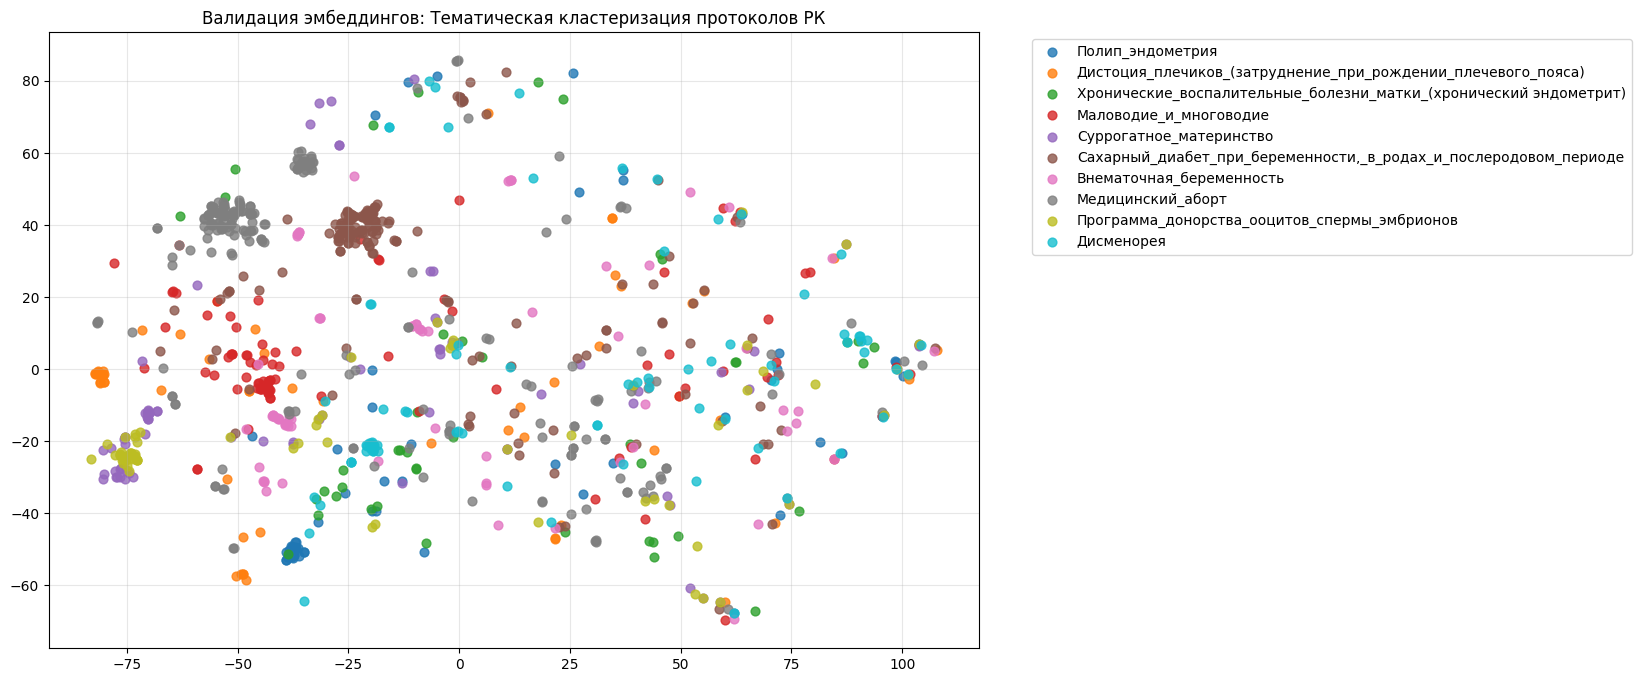

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import random

EMBEDDING_PATH = "/content/drive/MyDrive/medical_protocols/protocol_embeddings"

all_vectors = []
protocol_labels = []

files = [f for f in os.listdir(EMBEDDING_PATH) if f.endswith(".json")]
print(f"Загрузка {len(files)} протоколов для валидации...")

for file in files:
    protocol_name = file.replace("vec_", "").replace(".json", "")
    with open(os.path.join(EMBEDDING_PATH, file), 'r') as f:
        data = json.load(f)
        vectors = data.get('embeddings', [])
        all_vectors.extend(vectors)
        protocol_labels.extend([protocol_name] * len(vectors))

X = np.array(all_vectors)

if X.shape[0] == 0:
    print("❌ Ошибка: Не удалось загрузить ни одного эмбеддинга. Проверьте, что JSON-файлы в папке protocol_embeddings содержат ключ 'embeddings' с непустыми списками.")
else:
    print("Сжатие измерений (t-SNE)... это может занять минуту.")
    perplexity_val = min(30, X.shape[0] - 1) if X.shape[0] > 1 else 1 # Perplexity requires n_samples > 1
    if perplexity_val <= 0: # Handle case where X.shape[0] is 1 or 0
        print("Недостаточно данных для t-SNE (нужно более 1 образца).")
    else:
        tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42)
        X_embedded = tsne.fit_transform(X)

        plt.figure(figsize=(12, 8))
        df = pd.DataFrame({'x': X_embedded[:, 0], 'y': X_embedded[:, 1], 'label': protocol_labels})

        unique_protocols = df['label'].unique()
        if len(unique_protocols) > 10:
            top_protocols = random.sample(list(unique_protocols), 10)
        else:
            top_protocols = list(unique_protocols)

        for protocol in top_protocols:
            mask = df['label'] == protocol
            plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'], label=protocol, s=40, alpha=0.8)

        plt.title("Валидация эмбеддингов: Тематическая кластеризация протоколов РК")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.savefig("validation_tsne.png", dpi=300)
        print("✅ График сохранен как validation_tsne.png. Проверь его: точки одного цвета должны быть рядом!")
